In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys


sys.path.append("..")

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [100]:
from dataset.cyclone import CycloneDataset

data = CycloneDataset(
    path="/local01/bioinf/gyrokinetics/preprocessed",
    split="train",
    normalization="minmax",
    normalization_scope="dataset",
    spatial_ifft=True,
    trajectories=["cyclone5_2.h5", "cyclone6_2.h5", "cyclone7_2.h5", "cyclone10_2.h5", "cyclone12_2.h5"],
    separate_zf=False,
)

print(len(data))

925


In [111]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from pysteps.utils.spectral import rapsd
from matplotlib.animation import FuncAnimation


def plot_4x4_2D_raspec(x, **kwargs):
    _ = kwargs
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]

    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(20, 20))
    for i in range(5):
        for j in range(5):
            if [i, j] not in comb:
                ax[i, j].remove()

    imin = -1
    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])
        for n, (k, tgt) in enumerate(x.items()):
            yy = np.stack([tgt[0].permute(i, j, *other).numpy(), tgt[1].permute(i, j, *other).numpy()], axis=-1)
            slices = [tuple(np.random.randint(0, dim, size=50)) for dim in yy.shape[2:]]
            slices = list(zip(*slices))
            # slices = np.ndindex(*xx.shape[2:])  # all slices
            yy = np.complex64(yy)
            # raspec for each slice
            yy_raspec = [rapsd(yy[:, :, *sl], fft_method=np.fft) for sl in slices]
            yy_raspec_avg = np.mean(yy_raspec, axis=0)
            ax[i, j].loglog(yy_raspec_avg, lw=3, label=k, c=colormaps["tab20"](n))
        
        ax[i, j].grid(True)
        if i > imin:
            ax[i, j].set_ylabel(rf"${labels[i]}$ (A)", fontsize=20)
            ax[i, j].set_xlabel(rf"${labels[j]}$ ($\phi$)", fontsize=20)
            imin = i
    
    handles, labels = fig.gca().get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))
    fig.legend(unique_labels.values(), unique_labels.keys())
    return fig

def animate_4x4_raspec(data, subsample=10):
    fig, ax = plt.subplots(5, 5, figsize=(20, 20), layout="tight")
    comb = torch.combinations(torch.arange(5), 2).tolist()
    lines = {}  # Dictionary to store line objects for each subplot
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]
    imin = -1

    for i in range(5):
        for j in range(5):
            if [i, j] not in comb:
                ax[i, j].remove()
            else:
                line, = ax[i, j].loglog([], [], label="Pred spec", c="r", lw=3)
                lines[(i, j)] = line
                ax[i, j].grid(True)
                if i > imin:
                    ax[i, j].set_ylabel(rf"${labels[i]}$ (A)", fontsize=20)
                    ax[i, j].set_xlabel(rf"${labels[j]}$ ($\phi$)", fontsize=20)
                    imin = i

    def update(frame):
        fig.suptitle(f"K = {frame * subsample}", fontsize=32)
        
        for i, j in comb:
            other = tuple([o for o in range(5) if o != i and o != j])
            x1 = data[frame * subsample].x
            xx = np.stack([x1[0].permute(i, j, *other).numpy(), x1[1].permute(i, j, *other).numpy()], axis=-1)
            slices = [tuple(np.random.randint(0, dim, size=20)) for dim in xx.shape[2:]]
            slices = list(zip(*slices))
            xx_raspec = [rapsd(xx[:, :, *sl], fft_method=np.fft, normalize=True) for sl in slices]        
            xx_raspec_avg = np.mean(xx_raspec, axis=0)

            # Update the line data instead of clearing and redrawing
            lines[(i, j)].set_data(np.arange(len(xx_raspec_avg)), xx_raspec_avg)
            ax[i, j].relim()  # Recalculate limits
            ax[i, j].autoscale_view()  # Rescale the view

        return [lines[(i, j)] for i, j in comb]

    return FuncAnimation(fig, update, frames=len(data) // subsample, interval=1000, blit=True)

In [112]:
from diffusers import DDPMScheduler


min_noise_std = 1e-5
num_refinement_steps = 3

betas = [
    (min_noise_std ** (k / num_refinement_steps)) ** (1 / 3)
    for k in reversed(range(num_refinement_steps + 1))
]

ddpm = DDPMScheduler(
    num_train_timesteps=num_refinement_steps + 1,
    trained_betas=betas,
    prediction_type="v_prediction",
    clip_sample=False,
)

num_train_timesteps = ddpm.config.num_train_timesteps

In [113]:
vals = {}
x = data[70].x

for k in range(num_train_timesteps):
    step = torch.tensor(k)
    sigma = ddpm.alphas_cumprod.to(x.device)[step]
    noise_factor = sigma.view(-1, *[1 for _ in range(x.ndim - 1)])
    signal_factor = 1 - noise_factor
    noise = torch.randn_like(x)
    y_noised = ddpm.add_noise(x, noise, step)
    vals[f"{k}-in"] = y_noised
    # vals[f"{k}-noise"] = (noise_factor**0.5) * noise
    vals[f"{k}-tgt"] = (noise_factor**0.5) * noise + (signal_factor**0.5) * x
    print(k, sigma.item())

0 0.978455662727356
1 0.9026973843574524
2 0.6515164971351624
3 0.0


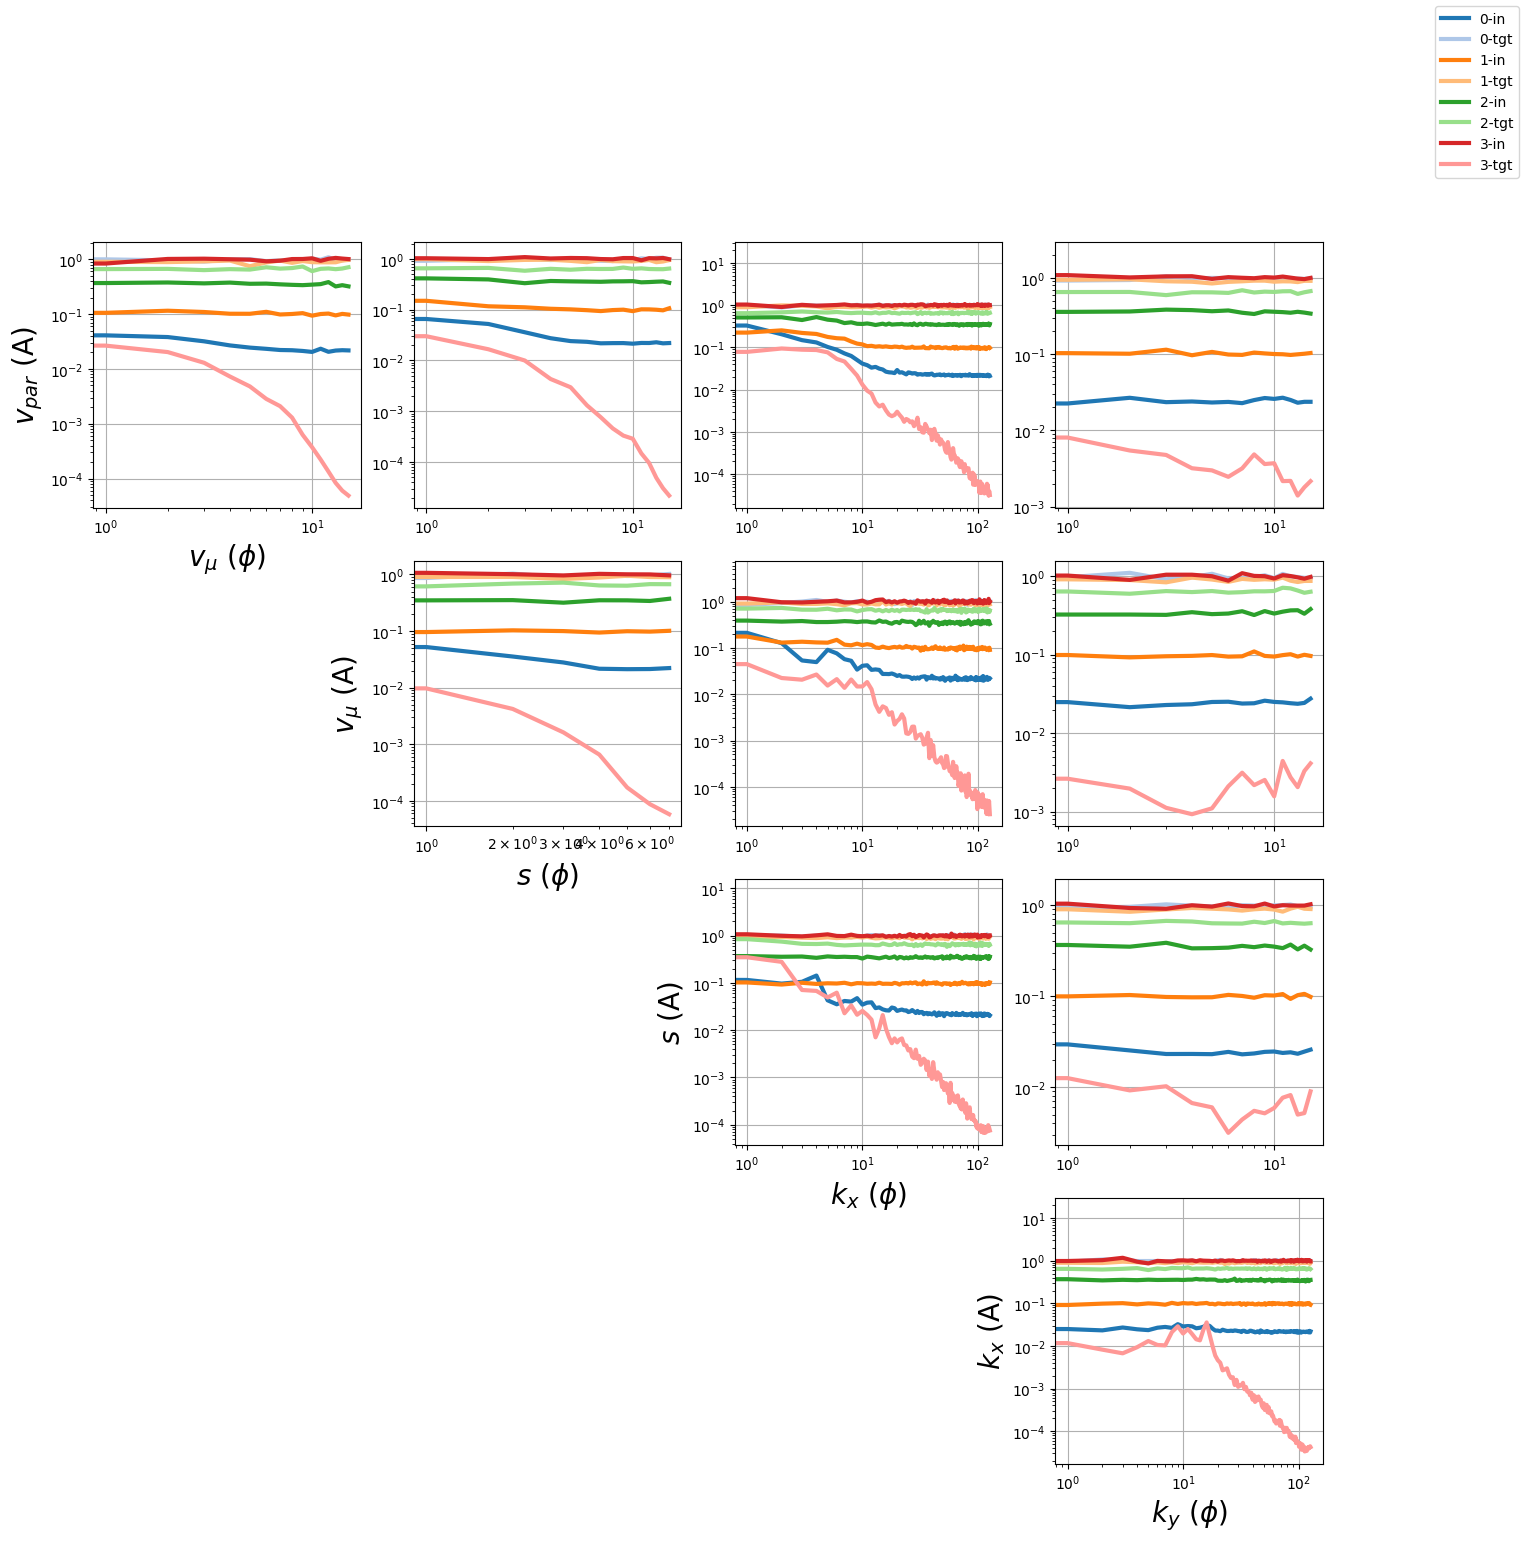

In [114]:
_ = plot_4x4_2D_raspec(vals)

In [96]:
from matplotlib import animation

writer = animation.FFMpegWriter(fps=10, bitrate=1800)
ani.save("spec.mp4", writer=writer)

In [15]:
import torch
from einops import rearrange

import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as tkr


def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot4x4_sided4times(dic, keys, average=True):
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(36, 20))
    for i in range(5):
        for j in range(5):
            if j == 0 or i == 4:
                ax[i, j].remove()
                continue
            ax_ij = ax[i, j]
            ax_ij.set_frame_on(False)
            ax_ij.tick_params(labelleft=False, labelbottom=False)
            ax_ij.set_xticks([])
            ax_ij.set_yticks([])

    c_map = matplotlib.colormaps["RdBu"]
    
    x1, x2, x3, x4 = [dic[k] for k in keys]

    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])

        if average:
            x1_plot = x1[0].mean(other)
            x2_plot = x2[0].mean(other)
            x3_plot = x3[0].mean(other)
            x4_plot = x4[0].mean(other)
        else:
            x1_plot = x1[0].permute(i, j, *other).numpy()
            x1_plot = x1_plot[
                :,
                :,
                x1_plot.shape[2] // 2,
                x1_plot.shape[3] // 2,
                x1_plot.shape[4] // 2,
            ]
            x2_plot = x2[0].permute(i, j, *other).numpy()
            x2_plot = x2_plot[
                :,
                :,
                x2_plot.shape[2] // 2,
                x2_plot.shape[3] // 2,
                x2_plot.shape[4] // 2,
            ]
            x3_plot = x3[0].permute(i, j, *other).numpy()
            x3_plot = x3_plot[
                :,
                :,
                x3_plot.shape[2] // 2,
                x3_plot.shape[3] // 2,
                x3_plot.shape[4] // 2,
            ]
            x4_plot = x4[0].permute(i, j, *other).numpy()
            x4_plot = x4_plot[
                :,
                :,
                x4_plot.shape[2] // 2,
                x4_plot.shape[3] // 2,
                x4_plot.shape[4] // 2,
            ]

        ax_ij = ax[i, j]
        pos = ax_ij.get_position()

        # Define the positions for four subplots in a 2x2 layout
        plot_width = 0.45 * pos.width
        plot_height = 0.45 * pos.height
        x_left_1 = pos.x0
        x_left_2 = x_left_1 + plot_width
        y_bottom_1 = pos.y0
        y_bottom_2 = y_bottom_1 + plot_height

        ax1 = fig.add_axes([x_left_1, y_bottom_2, plot_width, plot_height])  # Top-left
        ax2 = fig.add_axes([x_left_2, y_bottom_2, plot_width, plot_height])  # Top-right
        ax3 = fig.add_axes(
            [x_left_1, y_bottom_1, plot_width, plot_height]
        )  # Bottom-left
        ax4 = fig.add_axes(
            [x_left_2, y_bottom_1, plot_width, plot_height]
        )  # Bottom-right

        ax1.matshow(x1_plot, cmap=c_map)
        ax2.matshow(x2_plot, cmap=c_map)
        ax3.matshow(x3_plot, cmap=c_map)
        ax4.matshow(x4_plot, cmap=c_map)
        
        if i == 0:
            ax1.set_title(keys[0])
            ax2.set_title(keys[1])
            ax3.set_title(keys[2])
            ax4.set_title(keys[3])

        if j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3) or (i == 3 and j == 4):
            ax_ij.set_ylabel(rf"${labels[i]}$", fontsize=14)

        if i == 3 or j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3):
            ax_ij.set_xlabel(rf"${labels[j]}$", fontsize=14)

        # Remove axis ticks and labels
        for axx in [ax1, ax2, ax3, ax4]:
            axx.set_xticks([])
            axx.set_yticks([])
            axx.tick_params(labelleft=False, labelbottom=False)
            force_aspect(axx)

    return fig

In [ ]:
DATASETS = ["cyclone4_2_2.h5", "cyclone5_2.h5", "cyclone6_2.h5", "cyclone7_2.h5", "cyclone9_2.h5", "cyclone10_2.h5", "cyclone12_2.h5"]
NORMS = ["minmax"]


fig, ax = plt.subplots(2 * len(NORMS), len(DATASETS), figsize=(6 * len(DATASETS), 6 * len(NORMS)))
if ax.ndim == 1:
    ax = ax[:, None]

plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9, hspace=0.5, wspace=0.4)

for i, norm in enumerate(NORMS):
    full_data = CycloneDataset(
        path="/local01/bioinf/gyrokinetics/preprocessed",
        split="train",
        normalization=norm,
        normalization_scope="dataset",
        spatial_ifft=True,
        trajectories=DATASETS,
        separate_zf=False,
    )
    for j, traj in enumerate(DATASETS):
        data = CycloneDataset(
            path="/local01/bioinf/gyrokinetics/preprocessed",
            split="train",
            normalization=norm,
            normalization_scope="dataset",
            dataset_stats=full_data.dataset_stats,
            spatial_ifft=True,
            trajectories=[traj],
            separate_zf=False,
        )
        
        steps = list(range(0, len(data), 10))
        mins = []
        maxs = []
        means = []
        stds = []
        fluxes = []
        for k in steps:
            sample = data[k]
            x = sample.x
            mins.append(x.min().item())
            maxs.append(x.max().item())
            means.append(x.mean().item())
            stds.append(x.std().item())
            fluxes.append(sample.y_flux.item())
        
        fluxes = [0.5 * f / max(fluxes) for f in fluxes]

        ax[2 * i + 0, j].plot(steps, mins, label="mins")
        ax[2 * i + 0, j].plot(steps, maxs, label="maxs")
        ax[2 * i + 1, j].plot(steps, means, label="means")
        ax[2 * i + 1, j].plot(steps, stds, label="stds")
        # ax[2 * i + 1, j].plot(steps, fluxes, label="fluxes")
        ax[2 * i + 0, j].legend()
        ax[2 * i + 1, j].legend()
        ax[2 * i, j].set_title(f"{norm} ({traj})")

In [22]:
from models.swin_ae import SwinAE


model = SwinAE(
    space=5,
    dim=16,
    base_resolution=data.resolution,
    patch_size=(4, 2, 4, 8, 4),
    window_size=(4, 2, 2, 8, 4),
    depth=[2, 2],
    num_heads=[4, 8],
    in_channels=2,
    out_channels=2,
    num_layers=2,
    abs_pe=False,
    hidden_mlp_ratio=2.0,
    c_multiplier=2,
    merging_hidden_ratio=2.0,
    unmerging_hidden_ratio=4.0,
)

In [7]:
from torch.nn import functional as F

from train.losses import relative_norm_mse

opt = torch.optim.Adam(model.parameters(), 5e-4)
loader = torch.utils.data.DataLoader(data, 2, num_workers=4, shuffle=True, collate_fn=data.collate)

device = "cuda"

In [8]:
sample = data[60]
x = sample.x.to(device).unsqueeze(0)
y = sample.y.to(device).unsqueeze(0)

In [ ]:
model = model.to(device)
model.train()

for _ in range(50):
    loss = relative_norm_mse(model(x), x)
    # loss = F.mse_loss(model(x), x)
    
    opt.zero_grad()
    loss.backward()
    opt.step()
    print(f"1st loss = {loss:.4f}")

In [ ]:
model(x).std(), x.std()

In [23]:
sample = data[60]

In [24]:
with torch.no_grad():
    pred, lats = model.cpu()(sample.x.unsqueeze(0), return_latents=True)
    lats["input"] = rearrange(sample.x.unsqueeze(0), "b c ... -> b ... c")
    lats["output"] = rearrange(pred, "b c ... -> b ... c")
lats = {k: rearrange(l, "b ... c -> (b c) ...").numpy() for k, l in lats.items()}

In [ ]:
{k: f"{v.shape}, {v.mean():.2f}, {v.std():.2f}" for k, v in lats.items()}

In [ ]:
_ = plot4x4_sided4times(lats, ["input", "patch", "swin_pre0", "swin_down0"])

In [ ]:
_ = plot4x4_sided4times(lats, ["middle", "middle_up", "swin_up0", "output"])